# New IC → Residual Pipeline (WN-based, ZA Baseline)

Uses white-noise-derived psi1 (z=0) instead of Quijote ICs (z=127 2LPT snapshots).
`growth_factor_D = 1` because delta is already at z=0 scale.

In [1]:
print('Loading libraries and setting up environment...')

import sys, os
from pathlib import Path

nb_dir = Path.cwd()
if not (nb_dir / 'config.py').exists() and (nb_dir / 'src' / 'config.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import importlib
import config as cfg
import dddf

importlib.reload(cfg)
importlib.reload(dddf)

from dddf import DDDF

# ── Derived constants ──────────────────────────────────────────────
N_p        = cfg.N_p
L          = cfg.L
boxsize    = cfg.boxsize
MAS        = cfg.MAS
threads    = cfg.threads
grid_size  = N_p
data_dir   = cfg.data_dir
model_dir  = cfg.model_dir

print('Initializing DDDF (growth_factor_D=1) and Veck...')
dl        = DDDF(cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, data_dir={data_dir}, model_dir={model_dir}')
print(f'growth_factor_D = {dl.growth_factor_D}')

Loading libraries and setting up environment...
Initializing DDDF (growth_factor_D=1) and Veck...
hostname: nid001137
N_p=256, boxsize=1000.0, data_dir=baseline, model_dir=psi_vec_v3
growth_factor_D = 1.0


## 1. Training: IC → Residual

In [2]:
import numpy as np
from model.gen_patches import extract_patches
import model.train_model as train_module
from pipeline import compute_baseline, free_gpu_memory

importlib.reload(cfg)

patch_size = cfg.patch_size
padding    = cfg.padding
overlap    = cfg.overlap
rotate     = cfg.vec_rotate  # False for vector fields

# ── Section settings ──────────────────────────────────────────────
train_realizations = cfg.train_realizations   # e.g. list(range(16))
coef_file = None  # fit from scratch for WN-based pipeline
# ──────────────────────────────────────────────────────────────────

train_path = cfg.vec_training_data_path(
    train_realizations, patch_size, padding, overlap, rotate, N_p)

if os.path.exists(train_path):
    cached = np.load(train_path)
    input_patches  = cached['input_patches']
    target_patches = cached['target_patches']
    print(f'Combined training data already exists, loaded: {train_path}')
    print(f'{input_patches.shape[0]} patch pairs, shape {input_patches.shape[1:]}')
else:
    all_input_patches  = []
    all_target_patches = []

    for r in train_realizations:
        train_path_r = cfg.vec_training_data_path(
            r, patch_size, padding, overlap, rotate, N_p)
        if os.path.exists(train_path_r):
            cached = np.load(train_path_r)
            inp_r = cached['input_patches']
            tgt_r = cached['target_patches']
            print(f'  [r{r}] training file exists, loaded: {train_path_r}')
        else:
            # Load WN data
            wn_info_r = dl.get_snapshot_wn(
                cfg.wn_psi1_path(r, N_p),
                cfg.wn_qinit_path(r, N_p),
                boxsize, grid_size)
            q_init_r    = wn_info_r['q_init']
            init_delta_r = wn_info_r['delta']

            # Load final N-body snapshot
            final_info_r = dl.get_snapshot(
                cfg.final_snapshot_path(r, N_p),
                cfg.snapshot_format(N_p),
                boxsize, grid_size)

            # Compute target psi_div AND full displacement field
            tgt_psi_div_r, tgt_psi_r = dl.compute_target_psi_wn(
                q_init_r, final_info_r['pos'], N_p, boxsize, veck_main)

            # Compute Baseline (returns 4-tuple with vector psi)
            bf_psi_div_r, bf_psi_r, _, _ = compute_baseline(
                dl, init_delta_r, tgt_psi_div_r,
                q_init_r, final_info_r['delta'],
                veck_main, N_p, boxsize, MAS,
                r, data_dir, L,
                coef_file=coef_file,
                overwrite=False,
            )

            # Residual is in vector displacement space
            residual_psi_r = tgt_psi_r - bf_psi_r
            print(f'  [r{r}] residual psi chi^2 = {np.mean(residual_psi_r**2):.6e}')

            # Extract 4D patches: input=best_fit_psi (N,N,N,3), target=residual_psi (N,N,N,3)
            inp_r = extract_patches(bf_psi_r,       patch_size, padding, overlap, rotate)
            tgt_r = extract_patches(residual_psi_r, patch_size, padding, overlap, rotate)

            os.makedirs(os.path.dirname(train_path_r), exist_ok=True)
            np.savez(
                train_path_r,
                input_patches=inp_r,
                target_patches=tgt_r,
                patch_size=patch_size,
                padding=padding,
                overlap=overlap,
                realization=r,
            )
            print(f'  [r{r}] saved: {train_path_r}')
            del wn_info_r, final_info_r, tgt_psi_div_r, tgt_psi_r, bf_psi_div_r, bf_psi_r, residual_psi_r

        all_input_patches.append(inp_r)
        all_target_patches.append(tgt_r)

    input_patches  = np.concatenate(all_input_patches,  axis=0)
    target_patches = np.concatenate(all_target_patches, axis=0)
    assert input_patches.shape == target_patches.shape
    print(f'{input_patches.shape[0]} patch pairs from '
          f'{len(train_realizations)} realization(s), shape {input_patches.shape[1:]}')

    np.savez(train_path,
             input_patches=input_patches, target_patches=target_patches,
             patch_size=patch_size, padding=padding, overlap=overlap)
    print(f'combined training data saved: {train_path}')

/global/u1/l/liuyh15/WorkSpace/DDDF/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Combined training data already exists, loaded: /pscratch/sd/l/liuyh15/DDDF/ZA/data/psi_vec/training-data-VEC-N256PS20P2O00RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15.npz
35152 patch pairs, shape (24, 24, 24, 3)


In [12]:
free_gpu_memory()

importlib.reload(cfg)

# ── Section settings ──────────────────────────────────────────────
overwrite_train = False   # True -> force retrain
# ──────────────────────────────────────────────────────────────────

model_name = cfg.vec_gan_model_name(
    train_realizations, patch_size, padding, rotate, N_p)

train_module.train_gan(
    training_data_path=train_path,
    save_file_name=model_name,
    batch_size=cfg.vec_batch_size,
    epochs=cfg.epochs,          # 5 in config
    lr_g=cfg.gan_lr_g,
    lr_d=cfg.gan_lr_d,
    lambda_pixel=cfg.gan_lambda_pixel,
    n_disc_layers=cfg.gan_n_disc_layers,
    lambda_fm=cfg.gan_lambda_fm,
    lambda_gp=cfg.gan_lambda_gp,
    d_update_interval=cfg.gan_d_update_interval,
    use_multiscale_disc=cfg.gan_use_multiscale_disc,
    disc_base_channels=cfg.gan_disc_base_channels,
    checkpoint_interval=cfg.checkpoint_interval,
    resume_checkpoint='auto',
    overwrite=overwrite_train,
)

GPU memory in use: 0.07 GB
Detected 3 channel(s), spatial shape (24, 24, 24)
Auto-selected number of pooling levels: 4 (min side=24)
Generator base_channels: 32
Using device: cuda
Generator parameters: 10,044,867
Discriminator parameters: 1,135,810
n_channels=3, lambda_pixel=5.0, lambda_fm=20.0, n_disc_layers=3, d_update_interval=1, batch_size=512, use_multiscale_disc=True, disc_base_channels=64
Resuming training from checkpoint: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.ckpt
Completed 500 epochs, continue training to epoch 305.
Total training time: 0.1s
GAN training complete, generator saved to: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e305.pth


## 2. Verification

Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/psi1_grid_z127_seed000_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/q_init_seed000_n256.npz
psi1 grid: 256^3, dplus=101.025389, box_file=1000000.0 (kpc/h)
delta(z=0): mean=1.164153e-10, std=1.918638
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading baseline psi_div from /pscratch/sd/l/liuyh15/DDDF/ZA/data/baseline/baselineL1N256-0.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e300.pth (pools=4, device=cuda)


apply_model (patch-batch): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 1006.92it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=2.5s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


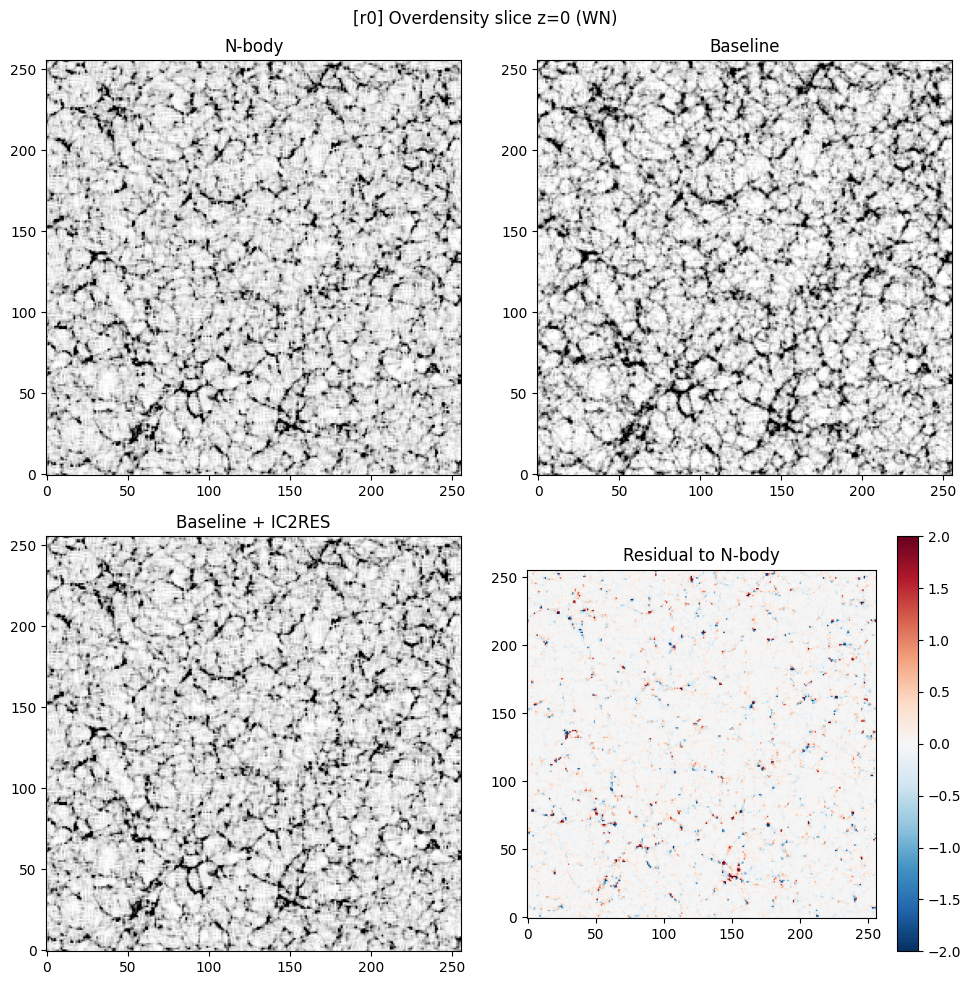

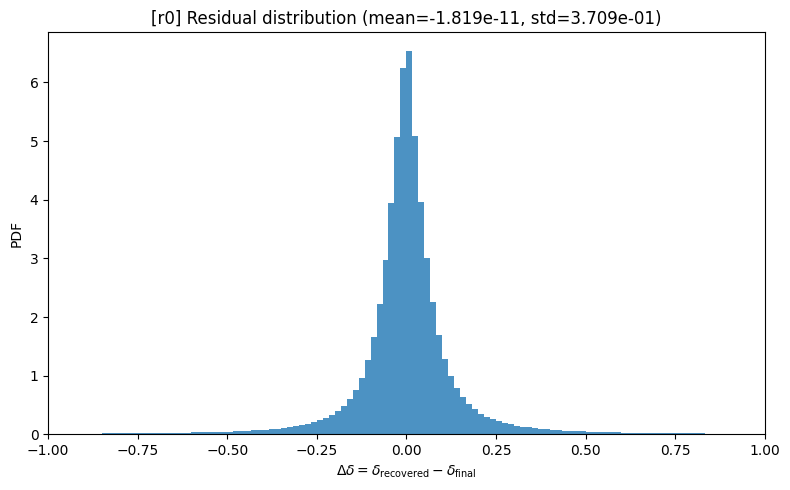

[r0] Nyquist target k = 0.804248, nearest-bin k = 0.807336


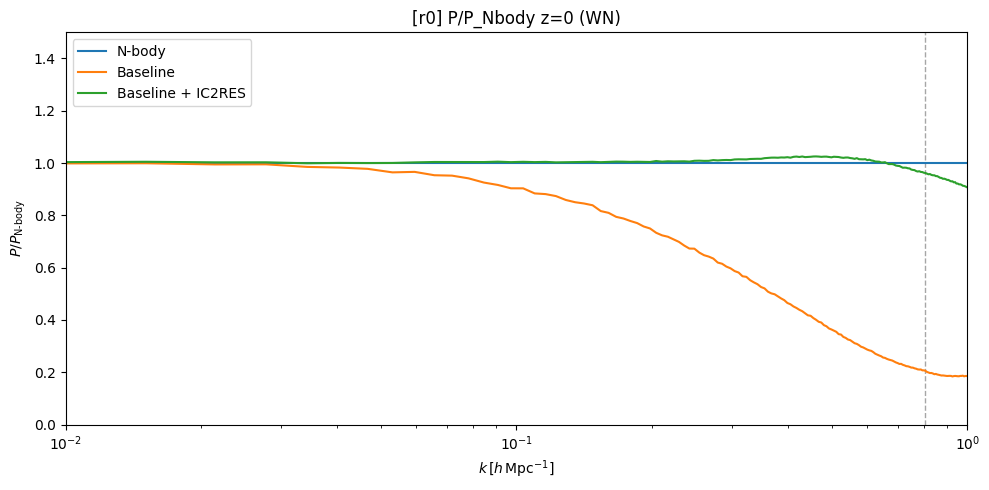

[r0] N-body P/P_N-body @Nyquist = 100.00%
[r0] Baseline P/P_N-body @Nyquist = 20.53%
[r0] Baseline + IC2RES P/P_N-body @Nyquist = 96.20%

Computing bispectrum of the field...
Time to compute bispectrum = 5.46

Computing bispectrum of the field...
Time to compute bispectrum = 5.45

Computing bispectrum of the field...
Time to compute bispectrum = 5.50


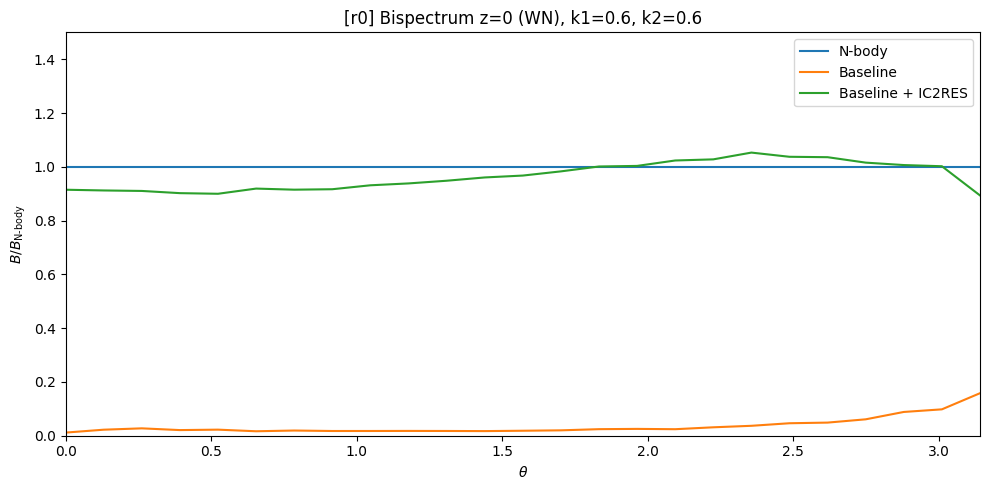

[r0] Baseline chi^2 (k<=0.3) = 5.085591e-02
[r0] Baseline + IC2RES chi^2 (k<=0.3) = 3.603993e-05
Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/psi1_grid_z127_seed019_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/q_init_seed019_n256.npz
psi1 grid: 256^3, dplus=101.025389, box_file=1000000.0 (kpc/h)
delta(z=0): mean=0.000000e+00, std=1.918345
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading baseline psi_div from /pscratch/sd/l/liuyh15/DDDF/ZA/data/baseline/baselineL1N256-19.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e300.pth (pools=4, device=cuda)


apply_model (patch-batch): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 814.99it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=3.0s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


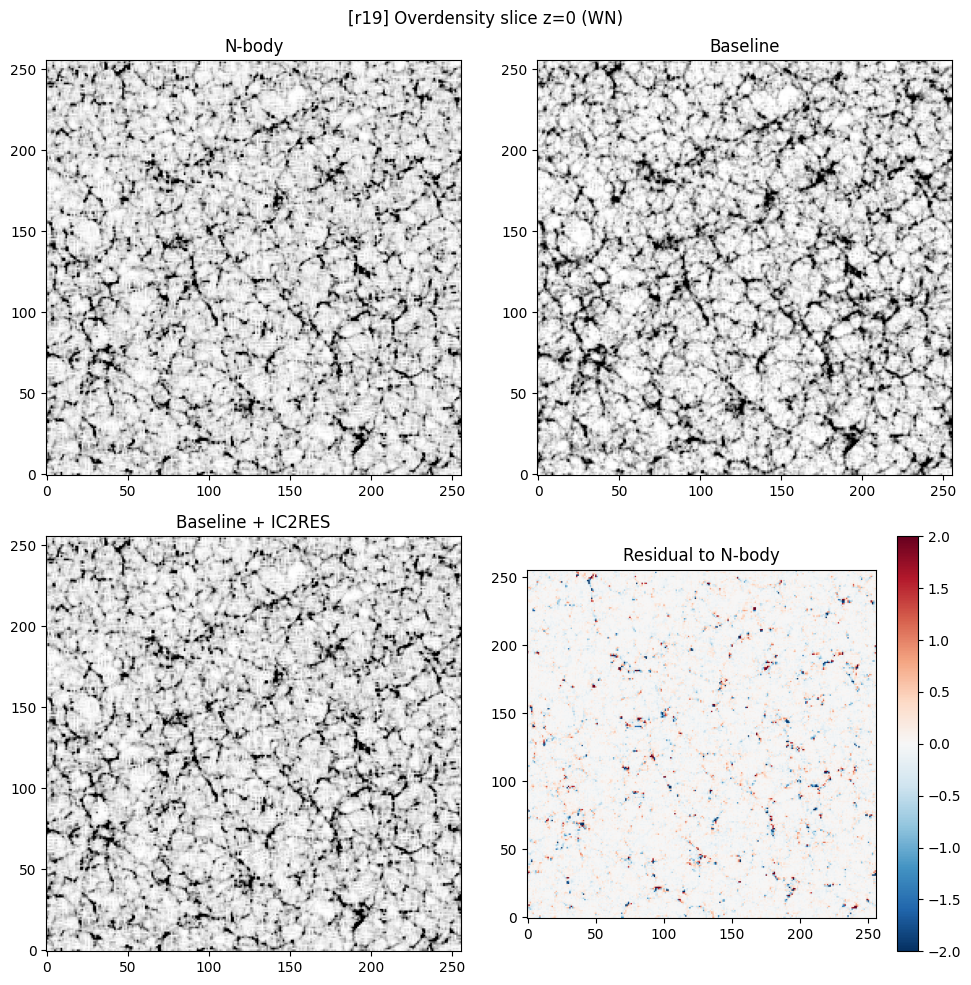

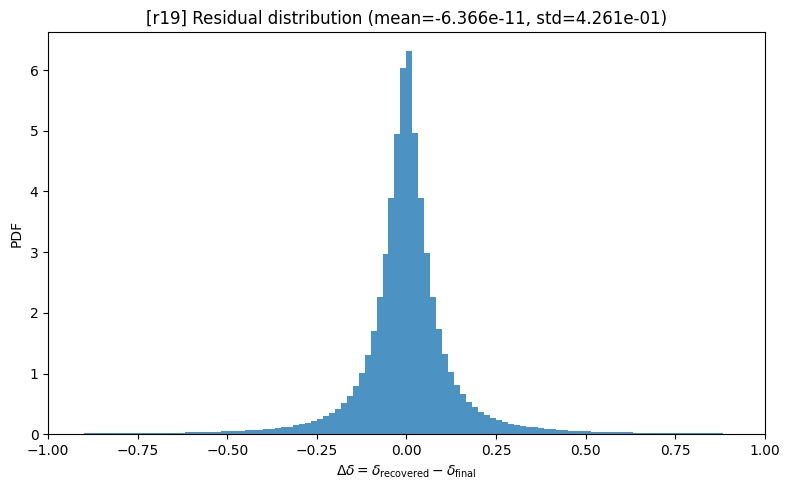

[r19] Nyquist target k = 0.804248, nearest-bin k = 0.807336


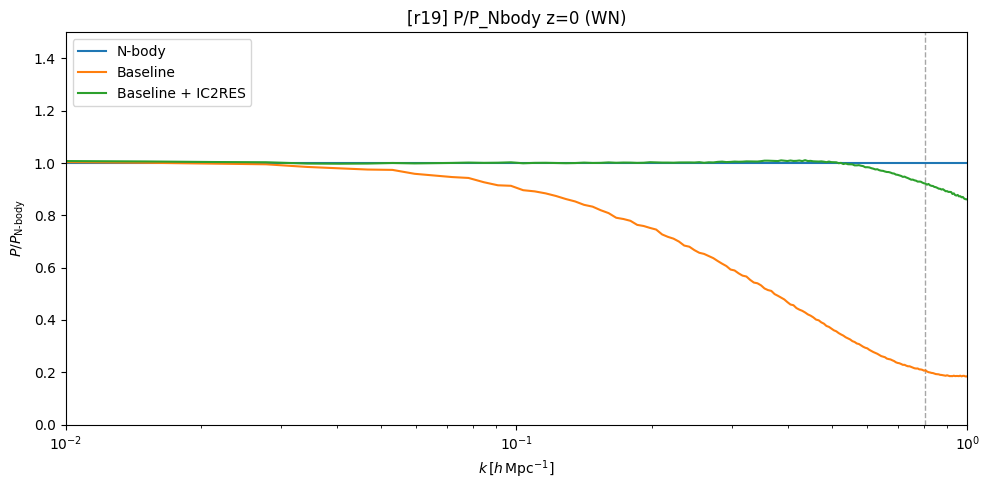

[r19] N-body P/P_N-body @Nyquist = 100.00%
[r19] Baseline P/P_N-body @Nyquist = 20.73%
[r19] Baseline + IC2RES P/P_N-body @Nyquist = 92.14%

Computing bispectrum of the field...
Time to compute bispectrum = 5.84

Computing bispectrum of the field...
Time to compute bispectrum = 5.67

Computing bispectrum of the field...
Time to compute bispectrum = 5.72


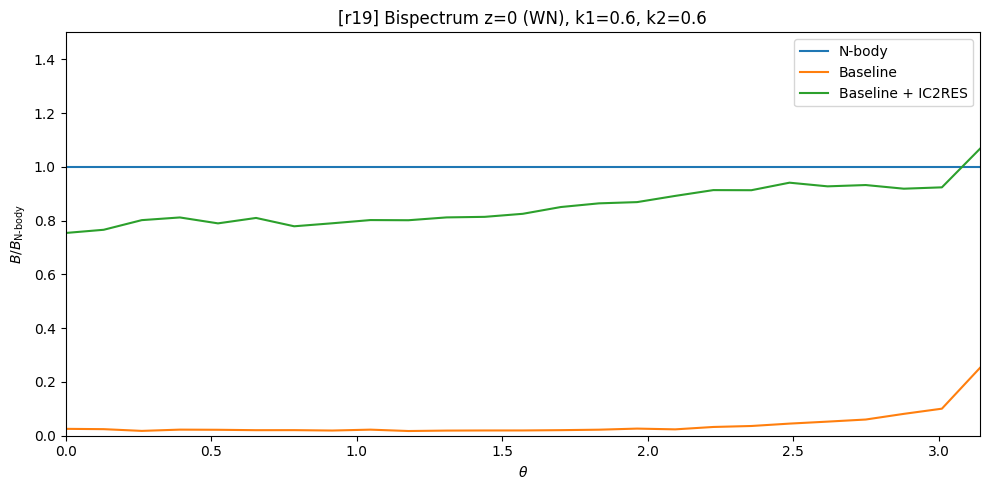

[r19] Baseline chi^2 (k<=0.3) = 5.047996e-02
[r19] Baseline + IC2RES chi^2 (k<=0.3) = 7.098621e-06


{'realization': 19,
 'checkpoint': '/pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e300.pth',
 'chi2': {'Baseline': 0.0504799570250019,
  'Baseline + IC2RES': 7.098621454068796e-06},
 'labels': ['N-body', 'Baseline', 'Baseline + IC2RES']}

In [18]:
importlib.reload(cfg)
import verify as verify_module
importlib.reload(verify_module)
from verify import verify_realization

k_cut = cfg.k_cut
verify_realization(realization=0, k_cut=k_cut, k1_bk=0.6, k2_bk=0.6)
verify_realization(realization=19, k_cut=k_cut, k1_bk=0.6, k2_bk=0.6)

Preparing fixed fields for realization=19 ...
Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/psi1_grid_z127_seed019_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/q_init_seed019_n256.npz
psi1 grid: 256^3, dplus=101.025389, box_file=1000000.0 (kpc/h)
delta(z=0): mean=0.000000e+00, std=1.918345
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading baseline psi_div from /pscratch/sd/l/liuyh15/DDDF/ZA/data/baseline/baselineL1N256-19.npz

Computing bispectrum of the field...
Time to compute bispectrum = 5.44

Computing bispectrum of the field...
Time to compute bispectrum = 5.49

Epoch losses from checkpoints:
epoch | loss_G | loss_D | file
   50 |  2.75490 | -0.14902 | gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e50.ckpt


apply_model (patch-batch): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 812.08it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=3.0s
Assigning displacements to particles using CIC...

Computing bispectrum of the field...
Time to compute bispectrum = 5.96
Done epoch 50: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e50.ckpt
  100 |      nan |      nan | gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e100.pth


apply_model (patch-batch): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 807.45it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=3.0s
Assigning displacements to particles using CIC...

Computing bispectrum of the field...
Time to compute bispectrum = 4.80
Done epoch 100: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e100.pth
  150 |  3.41024 | -0.11131 | gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e150.ckpt


...

apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=2.5s
Assigning displacements to particles using CIC...

Computing bispectrum of the field...
Time to compute bispectrum = 4.66
Done epoch 400: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e400.pth
  450 |  4.53800 | -0.11193 | gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e450.ckpt


apply_model (patch-batch): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 1010.37it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=2.5s
Assigning displacements to particles using CIC...

Computing bispectrum of the field...
Time to compute bispectrum = 5.49
Done epoch 450: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e450.ckpt
  500 |      nan |      nan | gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth


apply_model (patch-batch): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 813.97it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=3.0s
Assigning displacements to particles using CIC...

Computing bispectrum of the field...
Time to compute bispectrum = 5.82
Done epoch 500: /pscratch/sd/l/liuyh15/DDDF/ZA/models/psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth


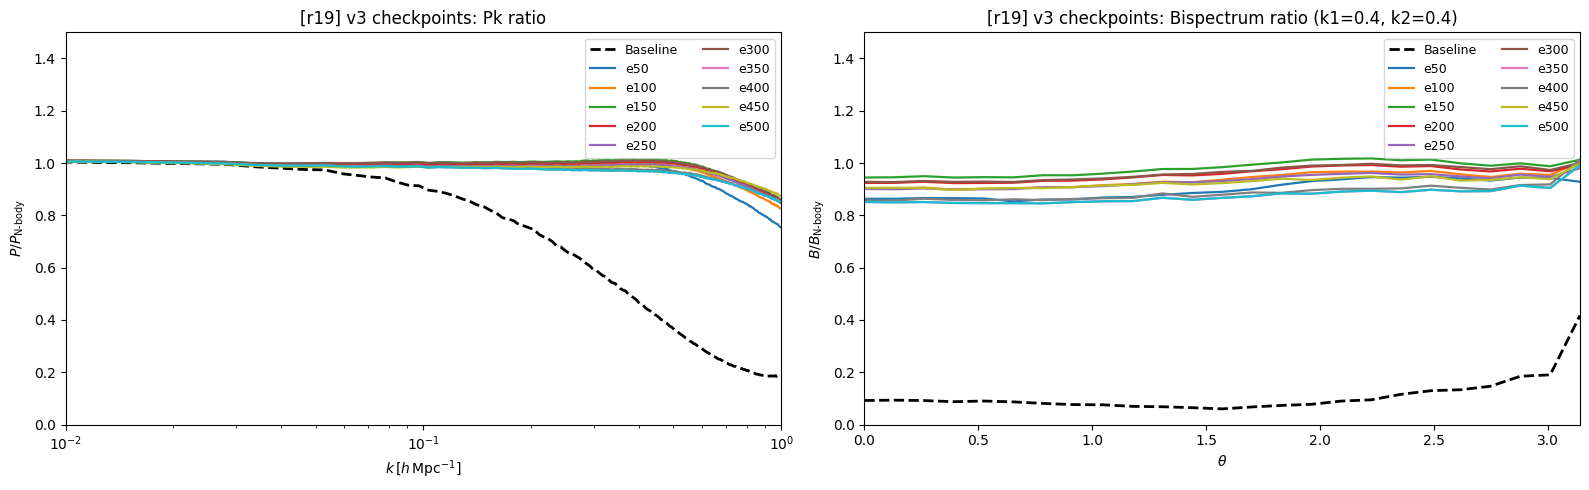

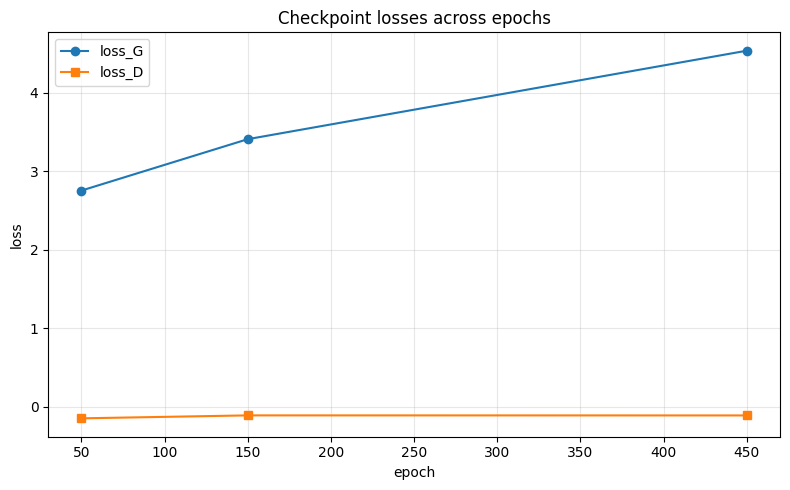

loss_G non-increasing: False
loss_D non-increasing: False


In [5]:
# v3 checkpoint comparison: plot Pk and bispectrum ratios for epochs 50..500
import os
import glob
import importlib

import numpy as np
import matplotlib.pyplot as plt
import torch
import Pk_library as PKL

import model.model as nnmodel
import config as cfg
import verify as verify_module
from pipeline import compute_baseline, psi_to_delta, highpass_vector_field
from inference import apply_model_to_field

importlib.reload(cfg)
importlib.reload(verify_module)

# ---- user settings ----
realization = 19
epoch_list = list(range(50, 501, 50))
k1, k2 = 0.4, 0.4
theta = np.linspace(0, np.pi, 25)
# -----------------------

N_p = cfg.N_p
boxsize = cfg.boxsize
MAS = cfg.MAS
threads = cfg.threads

# Reuse current notebook objects if already in memory
if 'dl' not in globals() or 'veck_main' not in globals():
    from dddf import DDDF
    dl        = DDDF(cfg.Omega_m, threads)
    veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'Preparing fixed fields for realization={realization} ...')
wn_info = dl.get_snapshot_wn(
    cfg.wn_psi1_path(realization, N_p),
    cfg.wn_qinit_path(realization, N_p),
    boxsize, N_p,
    )
q_init = wn_info['q_init']
init_delta = wn_info['delta']

final_info = dl.get_snapshot(
    cfg.final_snapshot_path(realization, N_p),
    cfg.snapshot_format(N_p),
    boxsize, N_p,
    )
final_delta = final_info['delta']

target_psi_div, target_psi = dl.compute_target_psi_wn(
    q_init, final_info['pos'], N_p, boxsize, veck_main
    )

baseline_psi_div, baseline_psi, baseline_delta, target_delta = compute_baseline(
    dl, init_delta, target_psi_div,
    q_init, final_delta,
    veck_main, N_p, boxsize, MAS,
    realization, cfg.data_dir, cfg.L,
    coef_file=None,
    overwrite=False,
    )

model_base = cfg.vec_gan_model_name(
    cfg.train_realizations, cfg.patch_size, cfg.padding, cfg.vec_rotate, cfg.N_p
    )
model_dir = os.path.dirname(model_base) or '.'
model_prefix = os.path.basename(model_base)

def _extract_generator_state(ckpt_obj):
    if isinstance(ckpt_obj, dict):
        if 'net_G_state' in ckpt_obj:
            return ckpt_obj['net_G_state']
        if 'state_dict' in ckpt_obj and isinstance(ckpt_obj['state_dict'], dict):
            sd = ckpt_obj['state_dict']
            g_sd = {}
            for k, v in sd.items():
                if k.startswith('net_G.'):
                    g_sd[k[len('net_G.'):]] = v
            if g_sd:
                return g_sd
        return ckpt_obj
    raise ValueError('Unsupported checkpoint object type')

def _strip_prefix_if_needed(state_dict, prefix):
    keys = list(state_dict.keys())
    if keys and all(k.startswith(prefix) for k in keys):
        return {k[len(prefix):]: v for k, v in state_dict.items()}
    return state_dict

def _load_generator_from_checkpoint(checkpoint_path, device, ckpt_obj=None):
    if ckpt_obj is None:
        ckpt_obj = torch.load(checkpoint_path, map_location='cpu')
    state_dict = _extract_generator_state(ckpt_obj)
    state_dict = _strip_prefix_if_needed(state_dict, 'module.')

    num_pools = verify_module._infer_num_pools(state_dict)
    inc_key = 'inc.double_conv.0.weight'
    if inc_key in state_dict:
        in_channels = state_dict[inc_key].shape[1]
        base_channels = state_dict[inc_key].shape[0]
    else:
        in_channels = 3
        base_channels = cfg.vec_unet_base_channels

    model = nnmodel.UNet3D(
        n_classes=in_channels,
        in_channels=in_channels,
        trilinear=True,
        base_channels=base_channels,
        num_pools=num_pools,
    )
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model

def _resolve_checkpoint_for_epoch(ep):
    candidates = [
        f"{model_base}-e{ep}.pth",
        f"{model_base}-e{ep}.ckpt",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p

    patterns = [
        os.path.join(model_dir, f"{model_prefix}-e{ep}.pth"),
        os.path.join(model_dir, f"{model_prefix}-e{ep}.ckpt"),
        os.path.join(model_dir, f"*-e{ep}.pth"),
        os.path.join(model_dir, f"*-e{ep}.ckpt"),
    ]
    found = []
    for pat in patterns:
        found.extend(glob.glob(pat))

    if found:
        found = sorted(set(found))
        vec_found = [p for p in found if 'gan-VEC-' in os.path.basename(p)]
        return vec_found[0] if vec_found else found[0]

    return None

# Reference spectra (N-body and ZA)
pk_target = PKL.Pk(target_delta, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False)
pk_baseline = PKL.Pk(baseline_delta, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False)
k_values = pk_target.k3D
pk_ratio_baseline = pk_baseline.Pk[:, 0] / pk_target.Pk[:, 0]

bk_target = PKL.Bk(target_delta, boxsize, k1, k2, theta, MAS=MAS, threads=threads)
bk_baseline = PKL.Bk(baseline_delta, boxsize, k1, k2, theta, MAS=MAS, threads=threads)
bk_ratio_baseline = np.divide(
    bk_baseline.B, bk_target.B,
    out=np.zeros_like(bk_baseline.B),
    where=np.abs(bk_target.B) > 0,
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = []
loss_records = []
missing = []

print('\nEpoch losses from checkpoints:')
print('epoch | loss_G | loss_D | file')
for ep in epoch_list:
    ckpt = _resolve_checkpoint_for_epoch(ep)
    if ckpt is None:
        missing.append(ep)
        continue

    ckpt_obj = torch.load(ckpt, map_location='cpu')
    loss_g = np.nan
    loss_d = np.nan
    if isinstance(ckpt_obj, dict):
        if 'loss_G' in ckpt_obj:
            loss_g = float(ckpt_obj['loss_G'])
        if 'loss_D' in ckpt_obj:
            loss_d = float(ckpt_obj['loss_D'])

    loss_records.append((ep, loss_g, loss_d, ckpt))
    print(f"{ep:5d} | {loss_g:8.5f} | {loss_d:8.5f} | {os.path.basename(ckpt)}")

    model = _load_generator_from_checkpoint(ckpt, device, ckpt_obj=ckpt_obj)

    residual_pred = apply_model_to_field(
        baseline_psi,
        model,
        cfg.infer_patch_size,
        cfg.infer_padding,
        cfg.infer_overlap,
        device,
        batch_size=cfg.infer_batch_size,
        )
    residual_pred = highpass_vector_field(
        residual_pred, cfg.k_cut, boxsize, width=cfg.k_width
        )

    final_psi = baseline_psi + residual_pred
    delta_final = psi_to_delta(final_psi, dl, q_init, N_p, boxsize, MAS)

    pk_final = PKL.Pk(delta_final, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False)
    pk_ratio = pk_final.Pk[:, 0] / pk_target.Pk[:, 0]

    bk_final = PKL.Bk(delta_final, boxsize, k1, k2, theta, MAS=MAS, threads=threads)
    bk_ratio = np.divide(
        bk_final.B, bk_target.B,
        out=np.zeros_like(bk_final.B),
        where=np.abs(bk_target.B) > 0,
        )

    results.append((ep, pk_ratio, bk_ratio))
    print(f"Done epoch {ep}: {ckpt}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pk panel
axes[0].set_xscale('log')
axes[0].set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$")
axes[0].set_ylabel(r"$P/P_{\rm N\text{-}body}$")
axes[0].set_xlim(0.01, 1.0)
axes[0].set_ylim(0.0, 1.5)
axes[0].plot(k_values, pk_ratio_baseline, color='black', ls='--', lw=2.0, label='Baseline')
for ep, pk_ratio, _ in results:
    axes[0].plot(k_values, pk_ratio, lw=1.6, label=f'e{ep}')
axes[0].set_title(f'[r{realization}] v3 checkpoints: Pk ratio')
axes[0].legend(ncol=2, fontsize=9)

# Bispectrum panel
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$B/B_{\rm N\text{-}body}$")
axes[1].set_xlim(0, np.pi)
axes[1].set_ylim(0.0, 1.5)
axes[1].plot(theta, bk_ratio_baseline, color='black', ls='--', lw=2.0, label='Baseline')
for ep, _, bk_ratio in results:
    axes[1].plot(theta, bk_ratio, lw=1.6, label=f'e{ep}')
axes[1].set_title(f'[r{realization}] v3 checkpoints: Bispectrum ratio (k1={k1}, k2={k2})')
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

# Loss figure and monotonic check
if loss_records:
    epochs_loss = np.array([x[0] for x in loss_records], dtype=int)
    loss_g_vals = np.array([x[1] for x in loss_records], dtype=float)
    loss_d_vals = np.array([x[2] for x in loss_records], dtype=float)

    valid_g = np.isfinite(loss_g_vals)
    valid_d = np.isfinite(loss_d_vals)

    fig, ax = plt.subplots(figsize=(8, 5))
    if np.any(valid_g):
        ax.plot(epochs_loss[valid_g], loss_g_vals[valid_g], 'o-', label='loss_G')
    if np.any(valid_d):
        ax.plot(epochs_loss[valid_d], loss_d_vals[valid_d], 's-', label='loss_D')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title('Checkpoint losses across epochs')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    if np.sum(valid_g) >= 2:
        is_g_nonincreasing = bool(np.all(np.diff(loss_g_vals[valid_g]) <= 0))
        print(f'loss_G non-increasing: {is_g_nonincreasing}')
    if np.sum(valid_d) >= 2:
        is_d_nonincreasing = bool(np.all(np.diff(loss_d_vals[valid_d]) <= 0))
        print(f'loss_D non-increasing: {is_d_nonincreasing}')
else:
    print('No loss values found in selected checkpoints.')

if missing:
    print('Missing checkpoints for epochs:', missing)
if not results:
    print('No checkpoints were found. Check model path and epoch list.')